# Cài đặt các Thư viện sử dụng

In [162]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [164]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [165]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [166]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt hiển thị dataFrame**

In [167]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**

In [168]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

# Khám phá dữ liệu

**Xem thông tin giữ liệu**

In [169]:
data_df.head(5)

title  \
0     Cấm biển di dân khỏi vùng nguy hiểm từ Quảng Ninh đến Nghệ An   
1  Hội Cựu Công an nhân dân là thành viên Mặt trận Tổ quốc Việt Nam   
2     Thêm 30 cá thể hổ và sư tử ở Vườn thú Mỹ Quỳnh (Long An) chết   
3                        Đà Lạt: Lũ cuốn trôi ô tô 1 người mất tích   
4       Kiên Giang: Cất bốc 19 hài cốt liệt sĩ tại huyện Kiên Lương   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

**Xáo trộn dữ liệu**

In [170]:
data_df=data_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [171]:
data_df.head(5)

title  \
0                                                               Lưỡi gỗ Nguyễn Viết Thông   
1               Biển Đông: Trung Quốc âm mưu chia rẽ Việt Nam và Philippines nên đoàn kết   
2                           Mất căn cước công dân ở nước ngoài tôi có được cấp lại không?   
3                                    Đường dây dùng trẻ em phục vụ khiêu dâm bị phát hiện   
4  Phạm Minh Hoàng: Hội Thánh Truyền Giáo Phục Hưng hay lãnh đạo CSVN gây lây nhiễm dịch?   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

**Mô tả dữ liệu**

In [172]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


In [173]:
data_df.describe().round(1)

,label
count,12600.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,1.0


**Kích thước của dataFrame và danh sách các tên cột**

In [174]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

(12600, 3)
['title', 'text', 'label']


**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [175]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
3


**Kiểm tra dữ liệu có bị lặp**

In [176]:
dup=data_df.index.duplicated().sum()
dup

0

**Kiểm tra dữ liệu có bị thiếu**

In [177]:
data_df['title'].isnull().sum()

0

In [178]:
data_df['text'].isnull().sum()

0

In [179]:
data_df['label'].isnull().sum()

0

**Kiểm tra loại dữ liệu**

In [180]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [181]:
open_object_dtype(data_df['title'])

{str}

In [182]:
open_object_dtype(data_df['text'])

{str}

In [183]:
open_object_dtype(data_df['label'])

{int}

**Kiểm tra số từ của title và text**

In [184]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [185]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,12600.000000,12600.000000
mean,13.281905,913.570556
std,4.446797,828.093960
min,1.000000,52.000000
25%,10.000000,384.000000
50%,14.000000,699.000000
75%,16.000000,1174.000000
max,47.000000,15495.000000


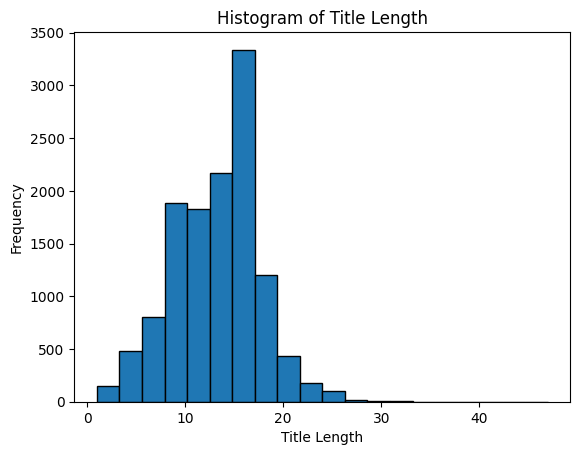

In [186]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

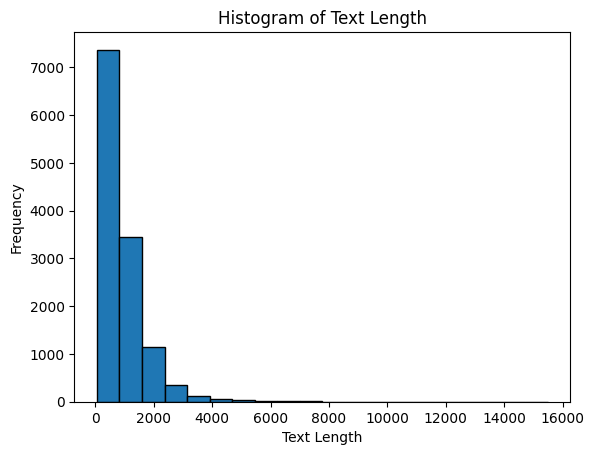

In [187]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

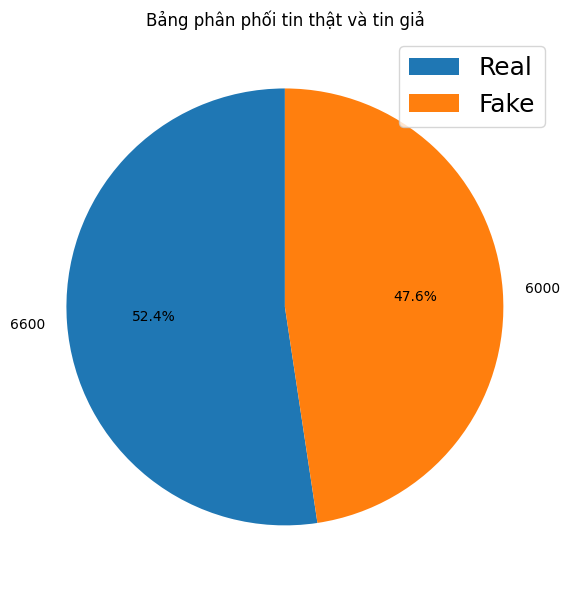

In [188]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [189]:
len_title_sum=0

for i in data_df['title']:
    len_word=i.split()
    len_title_sum += len(len_word)

avg_title=len_title_sum/data_df['title'].count()

avg_title

13.282619047619047

**Độ dài lớn nhất của tiêu đề**

In [190]:
max_title_len=0
for i in data_df['title']:
    len_word = i.split()
    if len(len_word) > max_title_len:
        max_title_len = len(len_word)
max_title_len

47

**Độ dài nhỏ nhất của tiêu đề**

In [191]:
min_title_len=max_title_len

for i in data_df['title']:
    len_word=i.split()
    if len(len_word) < min_title_len:
        min_title_len = len(len_word)

min_title_len

1

**Chiều dài trung bình text của 1 tin tức**

In [192]:
len_text_sum=0

for i in data_df['text']:
    len_word=i.split()
    len_text_sum += len(len_word)

avg_text=len_text_sum/data_df['text'].count()

avg_text

913.5705555555555

**Độ dài lớn nhất của text**

In [193]:
max_text_len=0

for i in data_df['text']:
    len_word=i.split()
    if len(len_word)>max_text_len:
        max_text_len=len(len_word)

max_text_len

15495

**Độ dài nhỏ nhất của text**

In [194]:
min_text_len = max_text_len

for i in data_df['text']:
    len_word=i.split()
    if len(len_word) < min_text_len:
        min_text_len = len(len_word)

min_text_len

52

**Tổng số từ trong title**

In [195]:
total_words = data_df['title'].str.split().map(len).sum()
total_words

167361

**Tổng số từ trong text**

In [196]:
total_words = data_df['text'].str.split().map(len).sum()
total_words

11510989

**Số từ khác biệt trong title**

In [197]:
unique_words = len(set(' '.join(data_df['title']).split()))
unique_words

11752

**Số từ khác biệt trong text**

In [198]:
unique_words = len(set(' '.join(data_df['text']).split()))
unique_words

115253

# Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

**Thư viện để xử lý**

In [199]:
from pyvi import ViTokenizer

**Loại bỏ các đường link và các dấu câu, lowercase**

In [200]:
def wordopt(text):
    text = text.lower()
    text = re.sub('[%s]' % re.escape("""!’‘–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…؛"""), ' ', text)
    text = re.sub('https?://\S+|www\.\S+|https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('<.*?>+', ' ', text)
    # text = re.sub('\[.*?\]', ' ', text)
    text = re.sub('\\W', ' ', text)
    # text = re.sub('\w*\d\w*', ' ', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.strip()

    # update_text = ""
    # for word in text.split():
    #     if word not in stopwords:
    #         update_text += word + " "
        
    return text

In [201]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)

**Hợp nhất title và text**

In [202]:
data_df['article'] = data_df["title"] +  data_df["text"] 

In [203]:
data_df.head(1)

title  \
0  Lưỡi gỗ Nguyễn Viết Thông   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

**Áp dụng các xử lý dữ liệu**

In [204]:
data_df['Compound_Content'] = data_df['article'].apply(wordopt)

In [205]:
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(tokenizerVN)

In [206]:
data_df.head(1)

title  \
0  Lưỡi gỗ Nguyễn Viết Thông   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

**Tổng số từ**

In [207]:
total_words = data_df['Compound_Content_SW'].str.split().map(len).sum()
total_words

8811806

**Số từ khác biệt còn lại**

In [208]:
unique_words_combined = len(set(' '.join(data_df['Compound_Content_SW']).split()))
unique_words_combined

73229

**Xác định tần suất xuất hiện các từ trong từng tài liệu**

In [209]:
from collections import Counter

In [210]:
word_counts_per_document = []

# Duyệt qua từng tài liệu
for doc in data_df['Compound_Content_SW']:
    words_in_doc = set(doc.split())  # Sử dụng set để loại bỏ từ trùng trong mỗi tài liệu
    word_counts_per_document.append(words_in_doc)

# Bước 4: Đếm tổng số lần xuất hiện của các từ trong tất cả các tài liệu (mỗi từ chỉ tính một lần trong một tài liệu)
total_word_counts = Counter()

# Duyệt qua danh sách các từ trong từng tài liệu và cập nhật tổng số đếm
for word_set in word_counts_per_document:
    total_word_counts.update(word_set)

In [211]:
print(len(total_word_counts))
for word, count in total_word_counts.most_common():
    print(f"{word}: {count/len(data_df)}")


73229
và: 0.9487301587301588
của: 0.9158730158730158
đã: 0.895
trong: 0.8924603174603175
cho: 0.8885714285714286
có: 0.8787301587301587
các: 0.8602380952380952
được: 0.8533333333333334
là: 0.8437301587301588
để: 0.8317460317460318
với: 0.8315873015873015
người: 0.826031746031746
đến: 0.824047619047619
về: 0.8161904761904762
trên: 0.7873809523809524
không: 0.777063492063492
đó: 0.768015873015873
khi: 0.7614285714285715
từ: 0.7524603174603175
ra: 0.7487301587301587
tại: 0.7408730158730159
theo: 0.7392063492063492
ở: 0.7333333333333333
một: 0.7326984126984127
những: 0.7265873015873016
vào: 0.7219047619047619
này: 0.6957142857142857
sau: 0.6949206349206349
ngày: 0.6811904761904762
bị: 0.6788888888888889
nhiều: 0.6746031746031746
năm: 0.6504761904761904
hơn: 0.6465079365079365
cũng: 0.6388888888888888
đang: 0.616031746031746
như: 0.6018253968253968
làm: 0.5992857142857143
trước: 0.591984126984127
lại: 0.5792857142857143
nam: 0.5769841269841269
qua: 0.5698412698412698
còn: 0.5694444444444444

# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [212]:
def tokenize(sentence):
    return tokenizerVN(sentence).split()

**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [213]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [214]:
model_vector_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_vectorizer_CV.joblib")
model_DTC_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_DTC_model_CV.joblib")
model_NB_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_NB_model_CV.joblib")
model_RFC_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_RFC_model_CV.joblib")
model_SVM_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_SVM_model_CV.joblib")
model_LR_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_LR_model_CV.joblib")
model_GBC_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_GBC_model_CV.joblib")


## Các mô hình vector

**Vẽ hình**

In [215]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

**Tính toán đánh giá**

In [216]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

In [217]:
def evaluate_model(y_true, y_pred, name_model, save=False):

    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }
    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/Vietnamese", f"Vietnamese_Evaluate_{name_model}.csv")
        
        metrics_df.to_csv(path_evaluate, index=False)

### CountVectorizer

In [218]:
vectorizerCV = CountVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=4,          
                            max_df=0.3,            
                            max_features=26305,              
                            ngram_range=(1, 3)        
                            )

In [219]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

In [220]:
joblib.dump(vectorizerCV, model_vector_CV)

['../../Model/Vietnamese/CV\\Vietnamese_vectorizer_CV.joblib']

**DecisionTreeClassifier**

In [221]:
dtc_cv = DecisionTreeClassifier(random_state=42)
dtc_cv.fit(Xv_trainCV,y_train)

DecisionTreeClassifier(random_state=42)

0.92
-------------------

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1605
           1       0.92      0.92      0.92      1545

    accuracy                           0.92      3150
   macro avg       0.92      0.92      0.92      3150
weighted avg       0.92      0.92      0.92      3150

-------------------



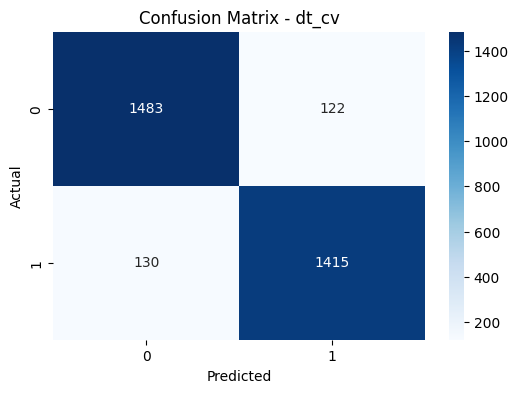

In [222]:
pred_dt_cv = dtc_cv.predict(Xv_testCV)
accuracy = accuracy_score(y_test, pred_dt_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dt_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dt_cv,name_model="dt_cv")

In [223]:
joblib.dump(dtc_cv, model_DTC_CV)

['../../Model/Vietnamese/CV\\Vietnamese_DTC_model_CV.joblib']

### Navie bayes

In [224]:
nb_cv = MultinomialNB()
nb_cv.fit(Xv_trainCV,y_train)

MultinomialNB()

0.9584126984126984
-------------------

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1605
           1       0.97      0.95      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



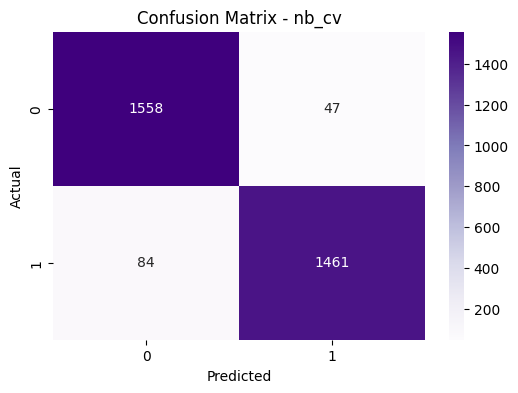

In [225]:
pred_nb_cv = nb_cv.predict(Xv_testCV)

accuracy = accuracy_score(y_test, pred_nb_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_nb_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_nb_cv,name_model="nb_cv")

In [226]:
joblib.dump(nb_cv, model_NB_CV)

['../../Model/Vietnamese/CV\\Vietnamese_NB_model_CV.joblib']

### RandomForest

In [227]:
rfc_cv = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_cv.fit(Xv_trainCV,y_train)

RandomForestClassifier(random_state=42)

0.973015873015873
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



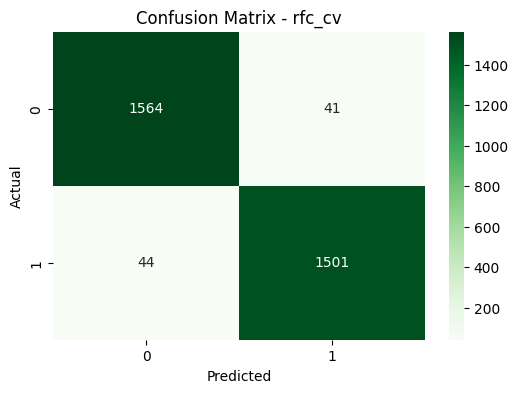

In [228]:
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv")

In [229]:
joblib.dump(rfc_cv, model_RFC_CV)

['../../Model/Vietnamese/CV\\Vietnamese_RFC_model_CV.joblib']

### SVM

In [230]:
svm_cv = LinearSVC(random_state=42)
svm_cv.fit(Xv_trainCV, y_train)

LinearSVC(random_state=42)

0.973015873015873
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



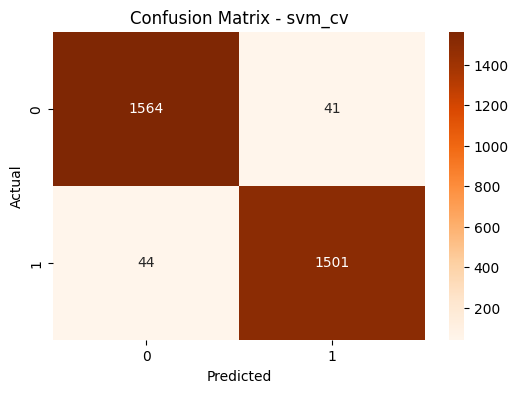

In [231]:
pred_svm_cv = svm_cv.predict(Xv_testCV)

accuracy = accuracy_score(y_test, pred_svm_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="svm_cv")

In [232]:
joblib.dump(svm_cv, model_SVM_CV)

['../../Model/Vietnamese/CV\\Vietnamese_SVM_model_CV.joblib']

### LogisticRegression

In [233]:
lr_cv = LogisticRegression(max_iter=1000, random_state=42)
lr_cv.fit(Xv_trainCV, y_train)
pred_lr_cv = lr_cv.predict(Xv_testCV)

0.9777777777777777
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1605
           1       0.98      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



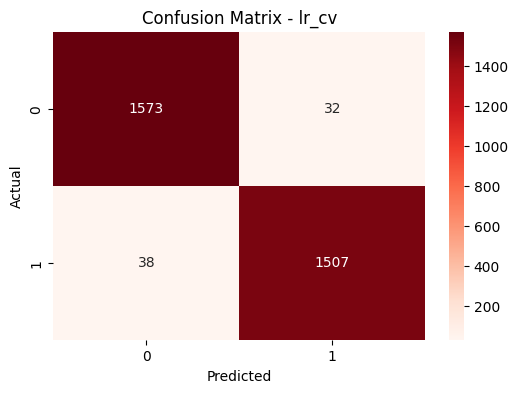

In [234]:
accuracy = accuracy_score(y_test, pred_lr_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_cv,name_model="lr_cv")

In [235]:
joblib.dump(lr_cv, model_LR_CV)

['../../Model/Vietnamese/CV\\Vietnamese_LR_model_CV.joblib']

### GradientBoostingClassifier

In [236]:
gbc_cv = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_cv.fit(Xv_trainCV, y_train)
pred_gbc_cv = gbc_cv.predict(Xv_testCV)

0.9622222222222222
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1605
           1       0.97      0.96      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



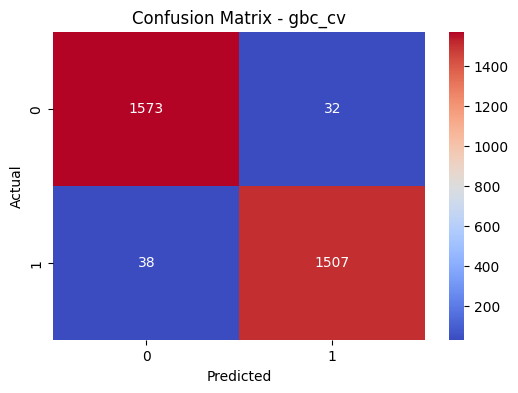

In [237]:
accuracy = accuracy_score(y_test, pred_gbc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_cv,name_model="gbc_cv")

In [238]:
joblib.dump(gbc_cv, model_GBC_CV)

['../../Model/Vietnamese/CV\\Vietnamese_GBC_model_CV.joblib']

## TfidfVectorizer

In [239]:
model_vector_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_vectorizer_TF.joblib")
model_DTC_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_DTC_model_TF.joblib")
model_NB_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_NB_model_TF.joblib")
model_RFC_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_RFC_model_TF.joblib")
model_SVM_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_SVM_model_TF.joblib")
model_LR_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_LR_model_TF.joblib")
model_GBC_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_GBC_model_TF.joblib")

In [240]:
vectorizerTF = TfidfVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=4,          
                            max_df=0.3,            
                            max_features=26305, 
                            use_idf=True, 
                            ngram_range=(1,3)
                            )

In [241]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

In [242]:
joblib.dump(vectorizerTF, model_vector_TF)

['../../Model/Vietnamese/TF\\Vietnamese_vectorizer_TF.joblib']

### DecisionTreeClassifier

In [243]:
dtc_tf = DecisionTreeClassifier(random_state=42)
dtc_tf.fit(Xv_trainTF,y_train)

DecisionTreeClassifier(random_state=42)

In [244]:
pred_dtc_tf = dtc_tf.predict(Xv_testTF)

0.9146031746031746
-------------------

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1605
           1       0.92      0.91      0.91      1545

    accuracy                           0.91      3150
   macro avg       0.91      0.91      0.91      3150
weighted avg       0.91      0.91      0.91      3150

-------------------



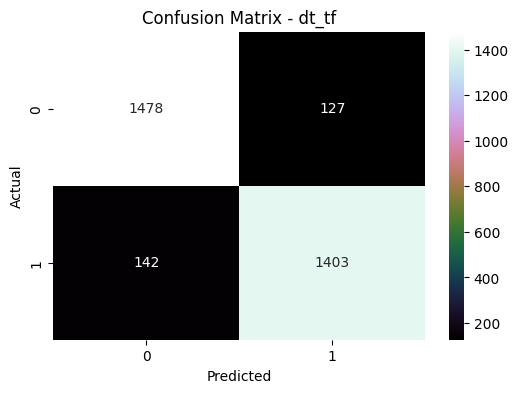

In [245]:
accuracy = accuracy_score(y_test, pred_dtc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dtc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dtc_tf,name_model="dt_tf")

In [246]:
joblib.dump(dtc_tf, model_DTC_TF)

['../../Model/Vietnamese/TF\\Vietnamese_DTC_model_TF.joblib']

### Navie bayes

In [247]:
nb_tf = MultinomialNB()
nb_tf.fit(Xv_trainTF,y_train)

MultinomialNB()

In [248]:
pred_nb_tf = nb_tf.predict(Xv_testTF)

0.9546031746031746
-------------------

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1605
           1       0.95      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



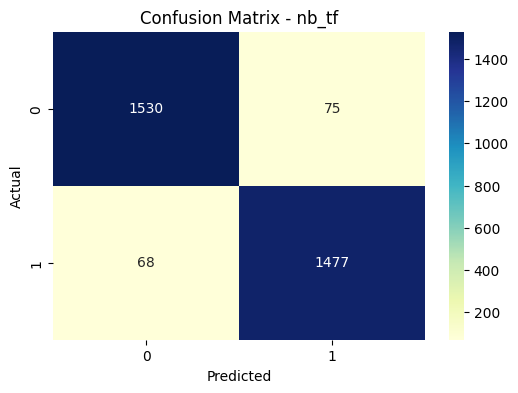

In [249]:
accuracy = accuracy_score(y_test, pred_nb_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_nb_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_nb_tf,name_model="nb_tf")

In [250]:
joblib.dump(nb_tf, model_NB_TF)

['../../Model/Vietnamese/TF\\Vietnamese_NB_model_TF.joblib']

### RandomForest

In [251]:
rfc_tf = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_tf.fit(Xv_trainTF,y_train)

RandomForestClassifier(random_state=42)

In [252]:
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

0.9736507936507937
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



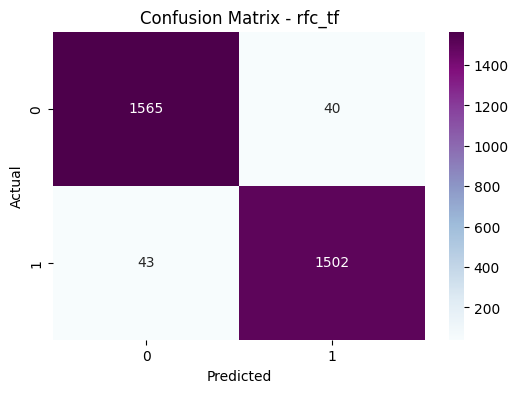

In [253]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf")

In [254]:
joblib.dump(rfc_tf, model_RFC_TF)

['../../Model/Vietnamese/TF\\Vietnamese_RFC_model_TF.joblib']

### SVM

In [255]:
svm_tf = LinearSVC(random_state=42)
svm_tf.fit(Xv_trainTF, y_train)

LinearSVC(random_state=42)

In [256]:
pred_svm_tf = svm_tf.predict(Xv_testTF)

0.9825396825396825
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1605
           1       0.99      0.97      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



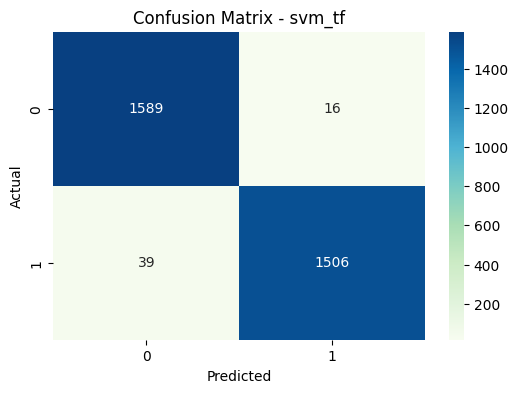

In [257]:
accuracy = accuracy_score(y_test, pred_svm_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_svm_tf,name_model="svm_tf")

In [258]:
joblib.dump(svm_tf, model_SVM_TF)

['../../Model/Vietnamese/TF\\Vietnamese_SVM_model_TF.joblib']

### LogisticRegression

In [259]:
lr_tf = LogisticRegression(max_iter=1000, random_state=42)
lr_tf.fit(Xv_trainTF, y_train)
pred_lr_tf = lr_tf.predict(Xv_testTF)

0.9752380952380952
-------------------

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1605
           1       0.98      0.97      0.97      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



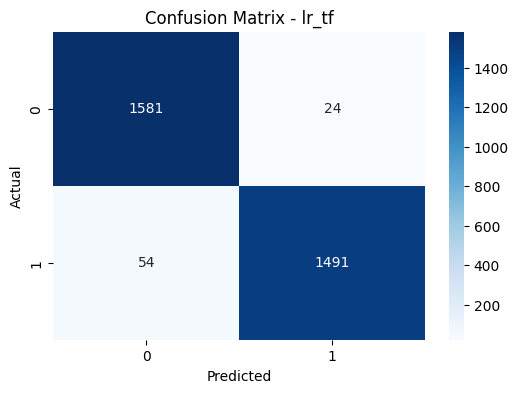

In [260]:
accuracy = accuracy_score(y_test, pred_lr_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_tf,name_model="lr_tf")

In [261]:
joblib.dump(lr_tf, model_LR_TF)

['../../Model/Vietnamese/TF\\Vietnamese_LR_model_TF.joblib']

### GradientBoostingClassifier

In [262]:
gbc_tf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_tf.fit(Xv_trainTF, y_train)
pred_gbc_tf = gbc_tf.predict(Xv_testTF)


0.959047619047619
-------------------

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1605
           1       0.96      0.95      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



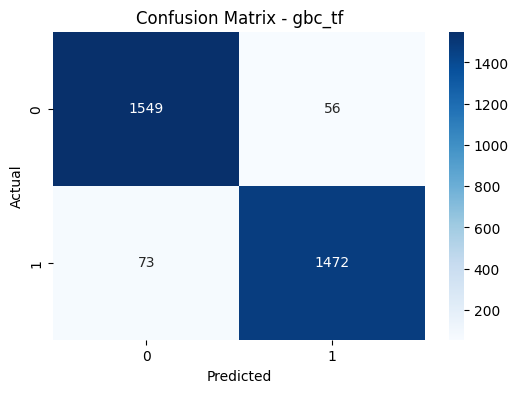

In [263]:
accuracy = accuracy_score(y_test, pred_gbc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_gbc_tf,name_model="gbc_tf")

In [264]:
joblib.dump(gbc_tf, model_GBC_TF)

['../../Model/Vietnamese/TF\\Vietnamese_GBC_model_TF.joblib']

## Word2Vec

In [265]:
model_vector_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_vectorizer_W2V.joblib")
model_DTC_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_DTC_model_W2V.joblib")
model_NB_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_NB_model_W2V.joblib")
model_RFC_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_RFC_model_W2V.joblib")
model_SVM_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_SVM_model_W2V.joblib")
model_LR_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_LR_model_W2V.joblib")
model_GBC_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_GBC_model_W2V.joblib")

In [266]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [267]:
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=150,  # Kích thước vector, có thể điều chỉnh để xem ảnh hưởng
    window=5,         # Kích thước cửa sổ ngữ cảnh
    min_count=4,      # Số lần tối thiểu từ phải xuất hiện để được giữ lại
    workers=4,        # Số lượng luồng để huấn luyện
    sg=1,             # Sử dụng Skip-gram (0 cho CBOW, 1 cho Skip-gram)
    epochs=20,        # Số lần lặp để huấn luyện
    negative=5,       # Số lượng negative samples cho mỗi positive sample
    alpha=0.025,      # Tỷ lệ học ban đầu
    min_alpha=0.00025,  # Tỷ lệ học nhỏ nhất
    seed=42           # Hạt giống để đảm bảo tính tái lặp
)

In [268]:
def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

In [269]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

In [270]:
joblib.dump(vectorizerW2V,model_vector_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_vectorizer_W2V.joblib']

### Decision Tree

In [271]:
dtc_w2v = DecisionTreeClassifier(random_state=42)
dtc_w2v.fit(Xv_trainW2V, y_train)

DecisionTreeClassifier(random_state=42)

In [272]:
pred_dtc_w2v = dtc_w2v.predict(Xv_testW2V)

0.9285714285714286
-------------------

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1605
           1       0.92      0.93      0.93      1545

    accuracy                           0.93      3150
   macro avg       0.93      0.93      0.93      3150
weighted avg       0.93      0.93      0.93      3150

-------------------



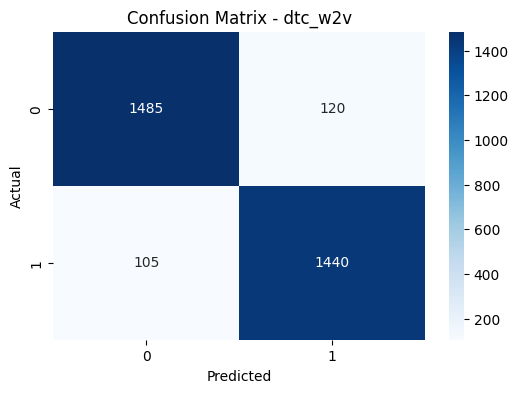

In [273]:
accuracy = accuracy_score(y_test, pred_dtc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dtc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dtc_w2v,name_model="dtc_w2v")

In [274]:
joblib.dump(dtc_w2v, model_DTC_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_DTC_model_W2V.joblib']

### Navie bayes

In [275]:
nb_w2v = GaussianNB()
nb_w2v.fit(Xv_trainW2V,y_train)

GaussianNB()

In [276]:
pred_np_w2v = nb_w2v.predict(Xv_testW2V)

0.9117460317460317
-------------------

              precision    recall  f1-score   support

           0       0.94      0.89      0.91      1605
           1       0.89      0.94      0.91      1545

    accuracy                           0.91      3150
   macro avg       0.91      0.91      0.91      3150
weighted avg       0.91      0.91      0.91      3150

-------------------



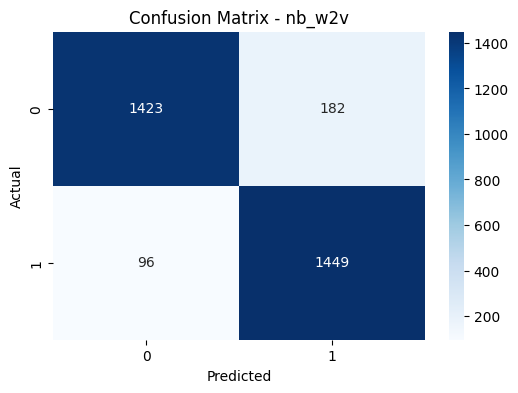

In [277]:
accuracy = accuracy_score(y_test, pred_np_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_np_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_np_w2v,name_model="nb_w2v")

In [278]:
joblib.dump(nb_w2v, model_NB_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_NB_model_W2V.joblib']

### RandomForest

In [279]:
rfc_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_w2v.fit(Xv_trainW2V, y_train)

RandomForestClassifier(random_state=42)

In [280]:
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

0.9666666666666667
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1605
           1       0.97      0.96      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



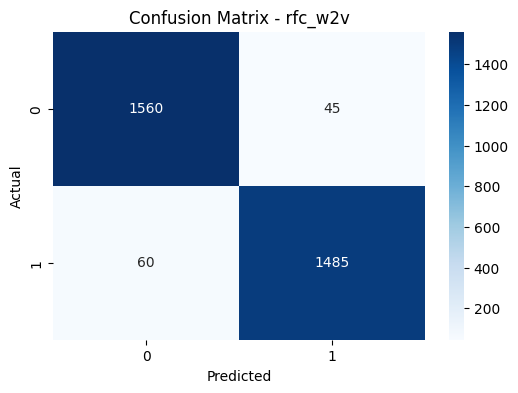

In [281]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v")

In [282]:
joblib.dump(rfc_w2v, model_RFC_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_RFC_model_W2V.joblib']

### SVM

In [283]:
svm_w2v = LinearSVC(random_state=42)
svm_w2v.fit(Xv_trainW2V, y_train)

LinearSVC(random_state=42)

In [284]:
pred_svm_w2v = svm_w2v.predict(Xv_testW2V)

0.9768253968253968
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1605
           1       0.97      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



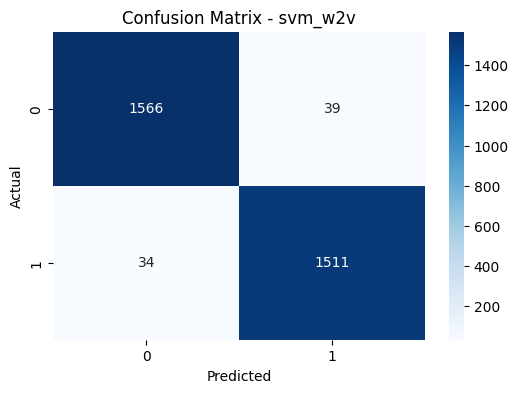

In [285]:
accuracy = accuracy_score(y_test, pred_svm_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_svm_w2v,name_model="svm_w2v")

In [286]:
joblib.dump(svm_w2v, model_SVM_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_SVM_model_W2V.joblib']

### LogisticRegression

In [287]:
lr_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_w2v.fit(Xv_trainW2V, y_train)
pred_lr_w2v = lr_w2v.predict(Xv_testW2V)

0.9698412698412698
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



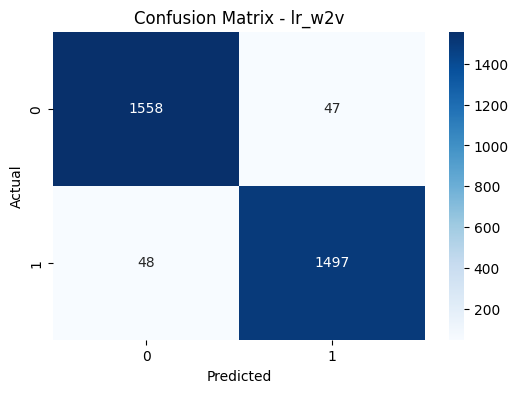

In [288]:
accuracy = accuracy_score(y_test, pred_lr_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_w2v,name_model="lr_w2v")

In [289]:
joblib.dump(lr_w2v, model_LR_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_LR_model_W2V.joblib']

### GradientBoostingClassifier

In [290]:
gbc_w2v = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_w2v.fit(Xv_trainW2V, y_train)
pred_gbc_w2v = gbc_w2v.predict(Xv_testW2V)

0.9685714285714285
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



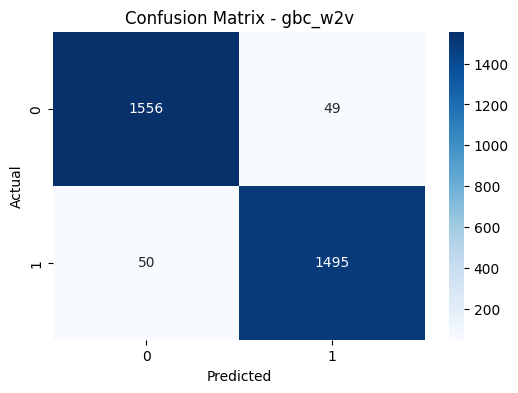

In [291]:
accuracy = accuracy_score(y_test, pred_gbc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_gbc_w2v,name_model="gbc_w2v")

In [292]:
joblib.dump(gbc_w2v, model_GBC_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_GBC_model_W2V.joblib']

## Doc2Vec

In [293]:
model_vector_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_vectorizer_D2V.joblib")
model_DTC_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_DTC_model_D2V.joblib")
model_NB_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_NB_model_D2V.joblib")
model_RFC_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_RFC_model_D2V.joblib")
model_SVM_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_SVM_model_D2V.joblib")
model_LR_D2V = os.path.join("../../Model/VietNamese/D2V", "VietNamese_LR_model_D2V.joblib")
model_GBC_D2V = os.path.join("../../Model/VietNamese/D2V", "VietNamese_GBC_model_D2V.joblib")

In [294]:
def preprocess(doc):
    tokens = tokenize(doc)
    return [word for word in tokens if word not in stopwords]

**Chuẩn bị dữ liệu**

In [295]:
X_train_preprocessed = [preprocess(doc) for doc in X_train]
X_test_preprocessed = [preprocess(doc) for doc in X_test]

In [296]:
documents = [TaggedDocument(preprocess(doc), [i]) for i, doc in enumerate(X_train)]

In [297]:
# Khởi tạo và huấn luyện mô hình Doc2Vec
vectorizerD2V = Doc2Vec(vector_size=150, window=5, min_count=4, workers=4, dm=1, negative=5, alpha=0.025, min_alpha=0.00025, seed=42)
vectorizerD2V.build_vocab(documents)
vectorizerD2V.train(documents, total_examples=vectorizerD2V.corpus_count, epochs=20)

In [298]:
print(f"Number of documents in the corpus: {vectorizerD2V.corpus_count}")

Number of documents in the corpus: 9450


In [299]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc) for doc in X_train_preprocessed]
Xv_testD2V = [vectorizerD2V.infer_vector(doc) for doc in X_test_preprocessed]

In [300]:
joblib.dump(vectorizerD2V, model_vector_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_vectorizer_D2V.joblib']

### DecisionTreeClassifier

In [301]:
dtc_d2v = DecisionTreeClassifier(random_state=42)
dtc_d2v.fit(Xv_trainD2V, y_train)

DecisionTreeClassifier(random_state=42)

In [302]:
pred_dtc_d2v = dtc_d2v.predict(Xv_testD2V)

0.7977777777777778
-------------------

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1605
           1       0.78      0.82      0.80      1545

    accuracy                           0.80      3150
   macro avg       0.80      0.80      0.80      3150
weighted avg       0.80      0.80      0.80      3150

-------------------



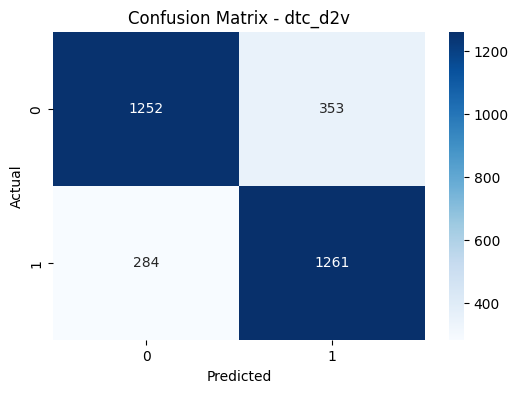

In [303]:
accuracy = accuracy_score(y_test, pred_dtc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dtc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dtc_d2v,name_model="dtc_d2v")

In [304]:
joblib.dump(dtc_d2v, model_DTC_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_DTC_model_D2V.joblib']

### Navie bayes

In [305]:
nb_d2v = GaussianNB()
nb_d2v.fit(Xv_trainD2V,y_train)

GaussianNB()

In [306]:
pred_nb_d2v = nb_d2v.predict(Xv_testD2V)

0.7333333333333333
-------------------

              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1605
           1       0.72      0.75      0.73      1545

    accuracy                           0.73      3150
   macro avg       0.73      0.73      0.73      3150
weighted avg       0.73      0.73      0.73      3150

-------------------



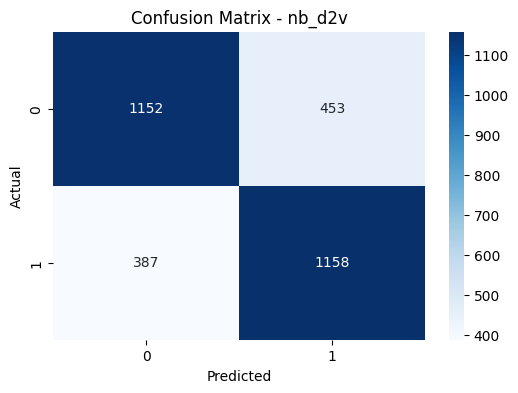

In [307]:
accuracy = accuracy_score(y_test, pred_nb_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_nb_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_nb_d2v,name_model="nb_d2v")

In [308]:
joblib.dump(nb_d2v, model_NB_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_NB_model_D2V.joblib']

### RandomForest

In [309]:
rfc_d2v = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_d2v.fit(Xv_trainD2V, y_train)

RandomForestClassifier(random_state=42)

In [310]:
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

0.9457142857142857
-------------------

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1605
           1       0.93      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



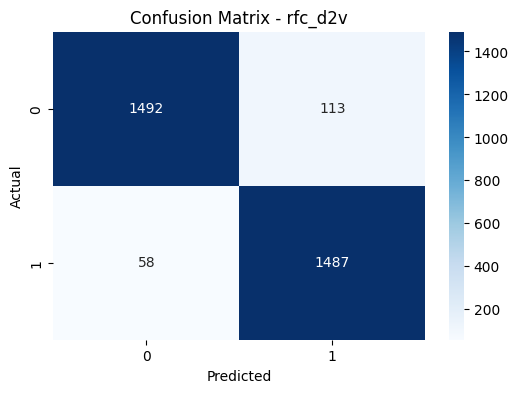

In [311]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v")

In [312]:
joblib.dump(rfc_d2v, model_RFC_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_RFC_model_D2V.joblib']

### SVM

In [313]:
svm_d2v = LinearSVC(random_state=42)
svm_d2v.fit(Xv_trainD2V, y_train)

LinearSVC(random_state=42)

In [314]:
pred_svm_d2v = svm_d2v.predict(Xv_testD2V)

0.9558730158730159
-------------------

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1605
           1       0.94      0.97      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



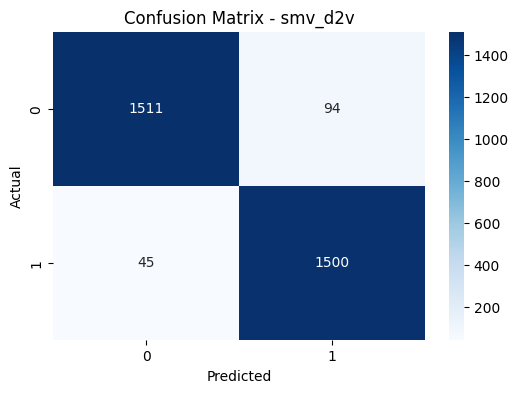

In [315]:
accuracy = accuracy_score(y_test, pred_svm_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_svm_d2v,name_model="smv_d2v")

In [316]:
joblib.dump(svm_d2v, model_SVM_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_SVM_model_D2V.joblib']

### LogisticRegression

In [317]:
lr_d2v = LogisticRegression(max_iter=1000, random_state=42)
lr_d2v.fit(Xv_trainD2V, y_train)
pred_lr_d2v = lr_d2v.predict(Xv_testD2V)

0.9555555555555556
-------------------

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1605
           1       0.94      0.97      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



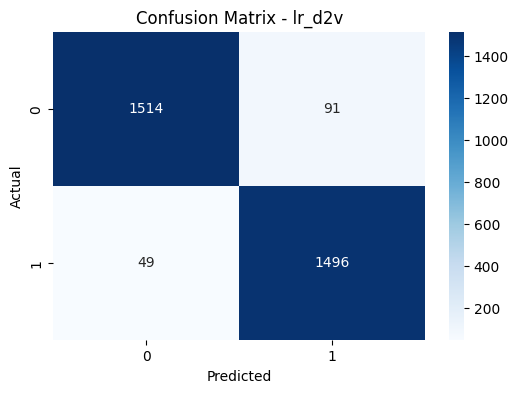

In [318]:
accuracy = accuracy_score(y_test, pred_lr_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_d2v,name_model="lr_d2v")

In [319]:
joblib.dump(lr_d2v, model_LR_D2V)

['../../Model/VietNamese/D2V\\VietNamese_LR_model_D2V.joblib']

### GradientBoostingClassifier

In [320]:
gbc_d2v = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_d2v.fit(Xv_trainD2V, y_train)
pred_gbc_d2v = gbc_d2v.predict(Xv_testD2V)

0.9396825396825397
-------------------

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1605
           1       0.93      0.95      0.94      1545

    accuracy                           0.94      3150
   macro avg       0.94      0.94      0.94      3150
weighted avg       0.94      0.94      0.94      3150

-------------------



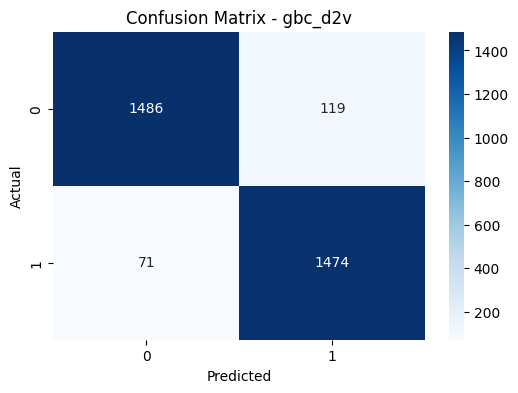

In [321]:
accuracy = accuracy_score(y_test, pred_gbc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_gbc_d2v,name_model="gbc_d2v")

In [322]:
joblib.dump(gbc_d2v, model_GBC_D2V)

['../../Model/VietNamese/D2V\\VietNamese_GBC_model_D2V.joblib']